## LUCAS SOIL 2018 DATA PREPARATION
### CONTENT
1) Data Cleaning
    - read data
    - inspect data
    - merge dataframes
    - additional checks
    - reduce to neccessary columns
    - final cleaning, delete rows with missing or wrong values
2) Data Transformation
    - add and calculate and transform columns
    - update datatypes
    - calculate quantils (...)
3) Final SHI Calculation
    - calculation with SHI formula

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1) Data Cleaning
### Reading the CSV files into Dataframes

In [2]:
# Read the data and check

df_bulk_density = pd.read_csv('01_input/BulkDensity_2018_final-2.csv')
df_soil_basic = pd.read_csv('01_input/LUCAS-SOIL-2018.csv')
df_texture = pd.read_csv('01_input/LUCAS_Text_All_10032025.csv')

# print(df_bulk_density.head())
# print(df_soil_basic.head())
# print(df_texture.head())

### Data inspection

In [3]:
# Show the headers of each df, also the dtype is displayed, still all are strings!

print(df_bulk_density.columns)
print(df_soil_basic.columns)
print(df_texture.columns)

# Check amount of rows and columns

print(df_bulk_density.info())
print(df_soil_basic.info())
print(df_texture.info())

# 6271 BD
# 18984 basic
# 27819 texture


Index(['POINT_ID', 'BD 0-10', 'BD 10-20', 'BD 20-30', 'BD 0-20'], dtype='str')
Index(['Depth', 'POINTID', 'pH_CaCl2', 'pH_H2O', 'EC', 'OC', 'CaCO3', 'P', 'N',
       'K', 'OC (20-30 cm)', 'CaCO3 (20-30 cm)', 'Ox_Al', 'Ox_Fe', 'NUTS_0',
       'NUTS_1', 'NUTS_2', 'NUTS_3', 'TH_LAT', 'TH_LONG', 'SURVEY_DATE',
       'Elev', 'LC', 'LU', 'LC0_Desc', 'LC1_Desc', 'LU1_Desc'],
      dtype='str')
Index(['POINTID', 'NUTS_0', 'Lucas2009', 'Lucas2012', 'Lucas2015', 'Lucas2018',
       'Coarse', 'Clay', 'Sand', 'Silt', 'PSDAvailable', 'TextureFromSurvey',
       'USDA', 'ISSS'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 6271 entries, 0 to 6270
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   POINT_ID  6271 non-null   int64  
 1   BD 0-10   6246 non-null   float64
 2   BD 10-20  5786 non-null   float64
 3   BD 20-30  140 non-null    float64
 4   BD 0-20   5761 non-null   float64
dtypes: float64(4), int64(1)
memory usa

### Merging the 3 Dataframes

In [4]:
# Rename POINTID to POINT_ID in df2 and df3
df_soil_basic = df_soil_basic.rename(columns={'POINTID': 'POINT_ID'})
df_texture = df_texture.rename(columns={'POINTID': 'POINT_ID'})

In [5]:
# merge the smallest and the second smallest dataframe on POINT_ID

df_bd_basic_merged = df_bulk_density.merge(
    df_soil_basic,
    on='POINT_ID',
    how='left',
    suffixes=('', '_from_soil_basic')  # avoids clashes if columns match
)

# check
# print(df_bd_basics_merged.info())
# print(df_bd_basics_merged.columns)

df_bd_basic_texture_merged = df_bd_basic_merged.merge(
    df_texture,
    on='POINT_ID',
    how='left',
    suffixes=('', '_from_texture')  # avoids clashes if columns match (NUTS_0 is the only duplicate col name)
)


### Additional Checks
- here i found that in 3 Datasets the NUTS_0, see notes.txt
- the code is identifiying the differences (3) and fills NaN values with values from the texture dataframe for NUTS_0

In [6]:
# If every row is identical, drop the duplicate column
# if (df_bd_basic_texture_merged['NUTS_0'] == df_bd_basic_texture_merged['NUTS_0_from_texture']).all():
#     df_bd_basic_texture_merged = df_bd_basic_texture_merged.drop(columns=['NUTS_0_from_texture'])

# # check
# print(df_bd_basic_texture_merged.info())
# print(df_bd_basic_texture_merged.columns)

# # NUTS_0_from_texture was not dropped, it holds not always identical values

# find the differences in NUTS_0 -> some are NaN
# diff_mask = df_bd_basic_texture_merged['NUTS_0'] != df_bd_basic_texture_merged['NUTS_0_from_texture']
# differences = df_bd_basic_texture_merged[diff_mask]
# print(differences[['POINT_ID', 'NUTS_0', 'NUTS_0_from_texture']])

# keep original NUTS_0 value if it exists, otherwise if it is NaN then fill it with NUTS_0_from_texture
df_bd_basic_texture_merged['NUTS_0'] = df_bd_basic_texture_merged['NUTS_0'].combine_first(df_bd_basic_texture_merged['NUTS_0_from_texture'])

# # If every row is now identical, drop the duplicate column
# if (df_bd_basic_texture_merged['NUTS_0'] == df_bd_basic_texture_merged['NUTS_0_from_texture']).all():
#     df_bd_basic_texture_merged = df_bd_basic_texture_merged.drop(columns=['NUTS_0_from_texture'])

# # check again
# print(df_bd_basic_texture_merged.info())
# print(df_bd_basic_texture_merged.columns)

# # find the differences in NUTS_0 -> some are NaN
# diff_mask = df_bd_basic_texture_merged['NUTS_0'] != df_bd_basic_texture_merged['NUTS_0_from_texture']
# differences = df_bd_basic_texture_merged[diff_mask]
# print(differences[['POINT_ID', 'NUTS_0', 'NUTS_0_from_texture']])


### Reduce to the necessary fields

In [7]:
# we keep df_bd_basic_texure_merged as it has now all possible columns
# we make a new df_soil_v1(version1) to work on and for further manipulation and cleaning
# we copy only the columns we need into that new df: 'POINT_ID', 'BD 0-20', 'Depth', 'pH_CaCl2', 'EC', 'OC', 'P', 'N', 'K', 'Clay'
# to change the wanted columns please see notes.txt for the whole choice
# print(df_bd_basic_texture_merged.columns)

columns_to_keep = ['POINT_ID', 'BD 0-20', 'Depth', 'pH_CaCl2', 'EC', 'OC', 'P', 'N', 'K', 'Clay']
df_soil_v1 = df_bd_basic_texture_merged[df_bd_basic_texture_merged.columns.intersection(columns_to_keep)]

# save the old and new df as a csv file in order to have better overview
df_bd_basic_texture_merged.to_csv("../output/df_bd_basic_texture_merged.csv", index=False)
df_soil_v1.to_csv("../output/df_soil_v1.csv", index=False)

# print(df_soil_v1.info())
# print(df_soil_v1.columns)
# print(df_soil_v1.head)

# Summary of numeric columns
print(df_soil_v1.describe())

# Count missing values per column
print(df_soil_v1.isna().sum())

# Check unique values for each column (good for categorical data like 'pH_CaCl2', 'Clay', etc.)
for col in df_soil_v1.columns:
    print(col, df_soil_v1[col].unique())


           POINT_ID      BD 0-20     pH_CaCl2           EC         Clay
count  6.271000e+03  5761.000000  6171.000000  6168.000000  6011.000000
mean   4.262895e+07     1.094102     5.748679    18.176305    20.102645
std    8.622725e+06     0.448558     1.404009    24.026794    13.604208
min    2.658177e+07    -0.018000     2.800000     0.240000     0.000000
25%    3.424204e+07     0.897000     4.600000     8.157500     9.000000
50%    4.448310e+07     1.144000     5.800000    13.930000    18.000000
75%    5.018363e+07     1.317000     7.100000    19.872500    28.000000
max    6.498167e+07     8.666000     8.400000   421.000000    92.000000
POINT_ID      0
BD 0-20     510
Depth        99
pH_CaCl2    100
EC          103
OC          100
P           105
N           100
K           100
Clay        260
dtype: int64
POINT_ID [30283550 26762002 27842416 ... 64841670 64881666 64981672]
BD 0-20 [0.289 1.42  0.955 ... 0.641 0.264 0.823]
Depth <StringArray>
['0-20 cm', '20-30 cm', '0-10 cm', nan, 

### Final step, remove rows with empty values, NaN or not fitting values

In [8]:
# Make another copy to work on, Replace empty strings with NaN, drop all rows where something is NaN
# drop rows where depth is not 0 - 20 cm, drop rows where something is < LOD

df_soil_v2 = df_soil_v1.copy()
df_soil_v2.replace('', np.nan, inplace=True)
df_soil_v2 = df_soil_v2.dropna()
df_soil_v2 = df_soil_v2[df_soil_v2['Depth'] == '0-20 cm']
cols_to_check = df_soil_v2.columns.difference(['POINT_ID', 'Depth'])
mask = ~(df_soil_v2[cols_to_check] == '< LOD').any(axis=1)
df_soil_v2 = df_soil_v2[mask]

print(df_soil_v2.info())

# save v2 to CSV, this is now a clean dataset with no missing or invalid values
df_soil_v2.to_csv("../output/df_soil_v2.csv", index=False)

<class 'pandas.DataFrame'>
Index: 3844 entries, 0 to 6269
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   POINT_ID  3844 non-null   int64  
 1   BD 0-20   3844 non-null   float64
 2   Depth     3844 non-null   str    
 3   pH_CaCl2  3844 non-null   float64
 4   EC        3844 non-null   float64
 5   OC        3844 non-null   str    
 6   P         3844 non-null   str    
 7   N         3844 non-null   str    
 8   K         3844 non-null   str    
 9   Clay      3844 non-null   float64
dtypes: float64(4), int64(1), str(5)
memory usage: 330.3 KB
None


## 2) Data Transformation

### Add and calculate columns, change datatypes
- calculation of EC in dS/m
- changing dtypes to float
- rename and drop columns as needed

In [9]:
# make another copy to work on, make a new column for depth_cm(int) and fill it with 20 (20cm)
df_soil_v3 = df_soil_v2.copy()
df_soil_v3["depth_cm"] = 20
# print(df_soil_v3.columns)
# print(df_soil_v3.head())

# change the dtype of all columns to float (depth and POINT_ID stay int) for further calculations
df_soil_v3["P"] = df_soil_v3["P"].astype(float)
df_soil_v3["N"] = df_soil_v3["N"].astype(float)
df_soil_v3["K"] = df_soil_v3["K"].astype(float)
df_soil_v3["BD 0-20"] = df_soil_v3["BD 0-20"].astype(float)
df_soil_v3["pH_CaCl2"] = df_soil_v3["pH_CaCl2"].astype(float)
df_soil_v3["EC"] = df_soil_v3["EC"].astype(float)
df_soil_v3["OC"] = df_soil_v3["OC"].astype(float)
df_soil_v3["Clay"] = df_soil_v3["Clay"].astype(float)

# we need EC in deciSiemens per meter, it comes in milliSiemens per meter, so /100 or * 0.01
df_soil_v3["EC_dS/m"] = (df_soil_v3["EC"]/100).round(4)

# drop the column Depth and EC as we have depth_cm and EC_dS_m now
# rename BD 0-20 to bulk_density_g/cm3 for better understanding, as well as OC and Clay and N, P, K
df_soil_v3.drop(columns=["Depth", "EC"], inplace=True)
df_soil_v3.rename(columns={"BD 0-20": "bulk_density_g/cm3"}, inplace=True)
df_soil_v3.rename(columns={"OC": "OC_g/kg"}, inplace=True)
df_soil_v3.rename(columns={"P": "P_mg/kg"}, inplace=True)
df_soil_v3.rename(columns={"N": "N_g/kg"}, inplace=True)
df_soil_v3.rename(columns={"K": "K_mg/kg"}, inplace=True)
df_soil_v3.rename(columns={"Clay": "Clay_pct"}, inplace=True)

# check
print(df_soil_v3.head())
# print(df_soil_v3.info())



   POINT_ID  bulk_density_g/cm3  pH_CaCl2  OC_g/kg  P_mg/kg  N_g/kg  K_mg/kg  \
0  30283550               0.289       3.9    265.7     10.5    15.0     88.2   
1  26762002               1.420       7.0      8.6     54.0     0.7    204.5   
2  27842416               0.955       3.7     91.6     14.6     6.9     61.2   
5  30303360               0.943       4.8     54.9     40.2     4.8     90.7   
6  27922412               0.972       4.2     85.5     21.1     7.1     77.6   

   Clay_pct  depth_cm  EC_dS/m  
0      13.0        20   0.0807  
1       7.0        20   0.1241  
2      13.0        20   0.1656  
5      13.0        20   0.1418  
6       9.0        20   0.1078  


### Calculation of N, P, K stocks in kg/ha and the Clay:SOC ratio
- defining functions
- calculation of the result columns

In [10]:
# defining a function to calculate the stock values in kg/ha for N, P and K
# it takes the value in the column (N, P or K) as concentration, bulk_density and depth as itself and unit has to be entered!
# for N it is g/kg and for P and K it is mg/kg
# the returned value is always in kg/ha (N, P or K)

def calc_stock(concentration, bulk_density, depth, unit):
    factors = {
        "mg/kg": 0.1,
        "g/kg": 100
    }
    
    if unit not in factors:
        raise ValueError(f"Unit '{unit}' not recognized. Use 'mg/kg' or 'g/kg'.")

    stock = (concentration * bulk_density * depth * factors[unit]).round(4)
    return stock

# function returns a number that represents the ratio of clay to SOC
# # we multiply by 10 as OC comes in g/kg which is 0,1% but we want 1% as Clay also comes in %
def calc_clay_SOC_ratio (clay, soc):
    ratio = np.where(soc == 0, np.nan, (clay / soc * 10).round(4))
    return ratio



# calculate the stocks for each element using the function calc_stock
df_soil_v3["P_kg/ha"] = calc_stock(
    df_soil_v3["P_mg/kg"],
    df_soil_v3["bulk_density_g/cm3"],
    df_soil_v3["depth_cm"],
    unit="mg/kg"
)

df_soil_v3["N_kg/ha"] = calc_stock(
    df_soil_v3["N_g/kg"],
    df_soil_v3["bulk_density_g/cm3"],
    df_soil_v3["depth_cm"],
    unit="g/kg"
)

df_soil_v3["K_kg/ha"] = calc_stock(
    df_soil_v3["K_mg/kg"],
    df_soil_v3["bulk_density_g/cm3"],
    df_soil_v3["depth_cm"],
    unit="mg/kg"
)

df_soil_v3["Clay_SOC_ratio"] = calc_clay_SOC_ratio(
    df_soil_v3["Clay_pct"],
    df_soil_v3["OC_g/kg"]
)

# check
# print(df_soil_v3.head())
# print(df_soil_v3.info())



In [11]:
# save v3 to CSV, this is now a clean dataset with units and ready for quantile calculation
df_soil_v3.to_csv("../output/df_soil_v3.csv", index=False)

### Quantiles & Bins
- Calculation of quantiles for 'Clay:SOC_ratio' and 'OC_g/kg'
- Introduction of predefined bins (bulk_density_g/cm3', 'pH_CaCl2', 'EC_dS/m', OC_g/kg', 'P_kg/ha', 'N_kg/ha', 'K_kg/ha')

In [12]:
# make another copy to work on, delete original N, P, K and Clay columns for better overview
df_soil_v4 = df_soil_v3.copy()
df_soil_v4.drop(columns=["P_mg/kg", "N_g/kg", "K_mg/kg", "Clay_pct"], inplace=True)

# check
# print(df_soil_v4.info())

In [13]:
# defining the quantiles
quantiles = [0.25, 0.50, 0.75]
quantile_clay_soc = df_soil_v4["Clay_SOC_ratio"].quantile(quantiles)
quantile_oc = df_soil_v4["OC_g/kg"].quantile(quantiles)

# Checking the quantiles for 'Clay_SOC_ratio' and 'OC_g/kg
print("Quantiles for Clay_SOC_ratio:\n", quantile_clay_soc)
print("Quantiles for OC_g/kg:\n", quantile_oc)

# calculate quantile labels for the two columns
quantile_labels_clay_soc = [4, 3, 2, 1]
df_soil_v4["Clay_SOC_score"] = pd.qcut(df_soil_v4["Clay_SOC_ratio"], q=4, labels=quantile_labels_clay_soc)

quantile_labels_oc = [1, 2, 3, 4]
df_soil_v4["OC_score"] = pd.qcut(df_soil_v4["OC_g/kg"], q=4, labels=quantile_labels_oc)

# change dtype to int (it is category otherwise)
df_soil_v4["Clay_SOC_score"] = df_soil_v4["Clay_SOC_score"].astype(int)
df_soil_v4["OC_score"] = df_soil_v4["OC_score"].astype(int)

# check the dataframe
print(df_soil_v4)

Quantiles for Clay_SOC_ratio:
 0.25     3.0389
0.50     7.8517
0.75    15.6250
Name: Clay_SOC_ratio, dtype: float64
Quantiles for OC_g/kg:
 0.25    12.800
0.50    20.400
0.75    38.525
Name: OC_g/kg, dtype: float64
      POINT_ID  bulk_density_g/cm3  pH_CaCl2  OC_g/kg  depth_cm  EC_dS/m  \
0     30283550               0.289       3.9    265.7        20   0.0807   
1     26762002               1.420       7.0      8.6        20   0.1241   
2     27842416               0.955       3.7     91.6        20   0.1656   
5     30303360               0.943       4.8     54.9        20   0.1418   
6     27922412               0.972       4.2     85.5        20   0.1078   
...        ...                 ...       ...      ...       ...      ...   
6263  64621644               0.999       7.6     15.4        20   0.2480   
6264  64581660               1.027       7.4      9.8        20   0.2060   
6266  64801668               1.365       7.3      8.2        20   0.1878   
6268  64841670           

In [14]:

# defining predefined bins for 'bulk_density_g/cm3', 'EC_dS/m', 'P_kg/ha', 'N_kg/ha', 'K_kg/ha'

# Labels ascending: P, N, K low = 1, high = 4
labels_asc = [1, 2, 3, 4]
bins_P = [0, 5, 10, 20, float('inf')]  # inf means "above 20"
bins_N = [0, 50, 100, 200, float('inf')]  # inf means "above 200"
bins_K = [0, 50, 100, 200, float('inf')]  # inf means "above 200"

# Labels descending: bulk density high = 1, low = 4, EC high = 1, low = 4
labels_desc = [4, 3, 2, 1]
bins_bulk_density = [0, 1.2, 1.4, 1.6, float('inf')] # inf means "above 1.6"
bins_EC = [0, 1.0, 2.0, 4.0, float('inf')] # inf means "above 4.0"


# calculating the label values according to bins

df_soil_v4["P_score"] = pd.cut(
    df_soil_v4["P_kg/ha"], 
    bins=bins_P, 
    labels=labels_asc, 
    right=True,    # right=True means the right edge is INCLUDED
    include_lowest=True  # makes the first bin include 0
)

df_soil_v4["N_score"] = pd.cut(
    df_soil_v4["N_kg/ha"], 
    bins=bins_N, 
    labels=labels_asc, 
    right=True,    # right=True means the right edge is INCLUDED
    include_lowest=True  # makes the first bin include 0
)

df_soil_v4["K_score"] = pd.cut(
    df_soil_v4["K_kg/ha"], 
    bins=bins_K, 
    labels=labels_asc, 
    right=True,    # right=True means the right edge is INCLUDED
    include_lowest=True  # makes the first bin include 0
)

df_soil_v4["bulk_density_score"] = pd.cut(
    df_soil_v4["bulk_density_g/cm3"], 
    bins=bins_bulk_density, 
    labels=labels_desc, 
    right=True,    # right=True means the right edge is INCLUDED ', '
    include_lowest=True  # makes the first bin include 0
)

df_soil_v4["EC_score"] = pd.cut(
    df_soil_v4["EC_dS/m"], 
    bins=bins_EC, 
    labels=labels_desc, 
    right=True,    # right=True means the right edge is INCLUDED
    include_lowest=True  # makes the first bin include 0
)

df_soil_v4["P_score"] = df_soil_v4["P_score"].astype(int)
df_soil_v4["N_score"] = df_soil_v4["N_score"].astype(int)
df_soil_v4["K_score"] = df_soil_v4["K_score"].astype(int)
df_soil_v4["bulk_density_score"] = df_soil_v4["bulk_density_score"].astype(int)
df_soil_v4["EC_score"] = df_soil_v4["EC_score"].astype(int)


In [15]:
# pH-CaCl score calculation

conditions = [
    (df_soil_v4["pH_CaCl2"] < 5.0) | (df_soil_v4["pH_CaCl2"] > 8.5),        # label 1: ph < 5.0, > 8.5
    ((df_soil_v4["pH_CaCl2"] >= 5.0) & (df_soil_v4["pH_CaCl2"] <= 6.0)) |   # label 2: ph 5.0 - 6.0 (includes 5.5-6.0), 7.5-8.5
    ((df_soil_v4["pH_CaCl2"] >= 7.5) & (df_soil_v4["pH_CaCl2"] <= 8.5)),
    ((df_soil_v4["pH_CaCl2"] >= 6.0) & (df_soil_v4["pH_CaCl2"] <= 6.5)) |   # label 3: ph 6.0 - 6.5, 7.0 - 7.5
    ((df_soil_v4["pH_CaCl2"] >= 7.0) & (df_soil_v4["pH_CaCl2"] <= 7.5)),
    ((df_soil_v4["pH_CaCl2"] > 6.5) & (df_soil_v4["pH_CaCl2"] < 7.0))       # label 4: ph 6.5 - 7.0
]

labels = [1, 2, 3, 4]

df_soil_v4["pH_score"] = np.select(conditions, labels, default=np.nan)
df_soil_v4["pH_score"] = df_soil_v4["pH_score"].astype(int)
# save v4 to CSV, this is now a dataset with scores according to quantiles or the predefined scales
df_soil_v4.to_csv("../output/df_soil_v4.csv", index=False)
print(df_soil_v4.columns)

Index(['POINT_ID', 'bulk_density_g/cm3', 'pH_CaCl2', 'OC_g/kg', 'depth_cm',
       'EC_dS/m', 'P_kg/ha', 'N_kg/ha', 'K_kg/ha', 'Clay_SOC_ratio',
       'Clay_SOC_score', 'OC_score', 'P_score', 'N_score', 'K_score',
       'bulk_density_score', 'EC_score', 'pH_score'],
      dtype='str')


## 3) Calculation of Soil Health Index (SHI)

- Weights: w_clay:soc 0.1, w_ph 0.05, w_ec 0.05, w_oc 0.25, w_P 0.1, w_N 0.1, w_K 0.1, w_bd 0.25
- Formula: SHI = Score(Clay) * Weight(Clay) + Score(pH) * Weight(pH) and so on


In [16]:
df_soil_data_with_SHI = df_soil_v4.copy()

weights = {
    'pH_score': 0.05,
    'EC_score': 0.05,
    'Clay_SOC_score': 0.10,
    'P_score': 0.10,
    'N_score': 0.10,
    'K_score': 0.10,
    'OC_score': 0.25,
    'bulk_density_score': 0.25
}

# Validate weights
assert abs(sum(weights.values()) - 1) < 1e-9, "Weights must sum to 1"

# function to calculate SHI (multiply each weight with corresponding column and add up all products)
def calc_shi(df, weights):
    return round(sum(df[col] * weight for col, weight in weights.items()),2)

# call the function
df_soil_data_with_SHI["SHI"] = calc_shi(df_soil_data_with_SHI, weights)

# print(df_soil_data_with_SHI)
# save to final CSV, this is now the date with an SHI for each row/soil point
df_soil_data_with_SHI.to_csv("../output/df_soil_data_with_SHI.csv", index=False)

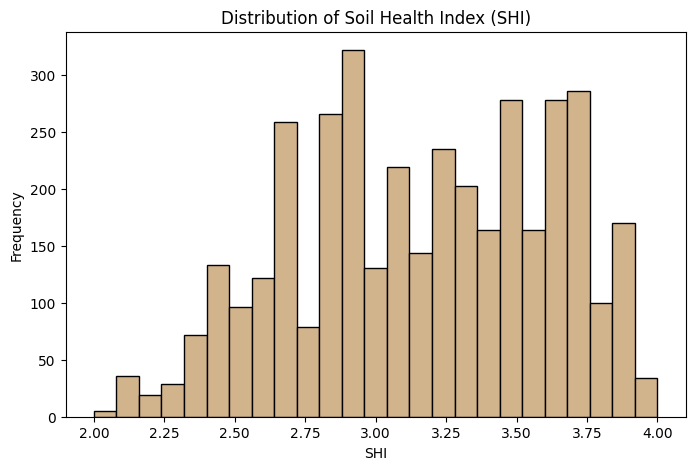

In [17]:
# Check how the SHI is spread
plt.figure(figsize=(8,5))

plt.hist(df_soil_data_with_SHI["SHI"], bins=25, edgecolor='black', color='tan')

plt.xlabel("SHI")
plt.ylabel("Frequency")
plt.title("Distribution of Soil Health Index (SHI)")

plt.show()